# Privacy-utility tradeoff for Private SpiderBoost on Criteo

Train Algorithm 2 of Arora et al. (ICML 2023) for several privacy budgets `ε` and compare final test ROC-AUC. Edit `EPSILONS` to sweep different values. Everything else (model, batches, `T`, `q`) is held fixed in `BASE`.

Each training run uses the full `T` steps. At the default config (`T=1500`) a run takes ~10–15 s on CPU.

**Note on the default ε range.** With `b1=8192` and `n≈800k`, the dominant term in `σ₁ = c·L₀·√log(1/δ)/ε · max(1/b1, √T/(qn))` is `1/b1 ≈ 1.2e-4`, so for ε ≳ 1 the noise is already negligible relative to the gradient signal and the AUC saturates. To see a meaningful tradeoff curve the default sweep includes very small ε (down to 0.01); at those budgets the noise becomes a significant fraction of the gradient norm and training quality degrades sharply.

In [6]:
import sys, pathlib

def _find_project():
    here = pathlib.Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / 'src' / 'data_loader.py').is_file():
            return p
    raise RuntimeError(f'Could not locate project root (no src/data_loader.py) from {here}')

PROJECT = _find_project()
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

from src.data_loader import load_criteo
from src.privacy_accountant import compute_noise_scales
from src.train import TrainConfig, train, evaluate_auc
from src import visualization as viz
import pandas as pd

In [7]:
DEVICE = 'cpu'  # 'cpu' or 'cuda'
from src.device import resolve_device
print(f'Using device: {resolve_device(DEVICE)}')

Using device: cpu:0


## 1. Load data (once)

In [8]:
DATA_PATH = PROJECT / 'data' / 'criteo_1M.parquet'
FIGS_DIR  = PROJECT / 'figs'
FIGS_DIR.mkdir(exist_ok=True)

data = load_criteo(DATA_PATH, test_fraction=0.2, seed=0, device=DEVICE)
n_train, d = data.x_train.shape
print(f'train: {data.x_train.shape}   test: {data.x_test.shape}')

train: (800000, 13)   test: (200000, 13)


## 2. Sweep configuration

Edit `EPSILONS` to change the values that are tested. `BASE` holds everything else.

In [9]:
EPSILONS = [0.01, 0.03, 0.1, 0.3, 1.0, 10.0]

BASE = dict(
    delta       = 1 / (1.1 * n_train),
    L0          = 3.0,
    L1          = 5.0,
    T           = 1500,
    q           = 30,
    b1          = 8192,
    b2          = 512,
    eta         = 0.01,
    hidden_dims = (64, 32),
    seed        = 0,
)
BASE

{'delta': 1.1363636363636362e-06,
 'L0': 3.0,
 'L1': 5.0,
 'T': 1500,
 'q': 30,
 'b1': 8192,
 'b2': 512,
 'eta': 0.01,
 'hidden_dims': (64, 32),
 'seed': 0}

## 3. Run the sweep

In [10]:
records = []
for eps in EPSILONS:
    cfg = TrainConfig(epsilon=eps, device=DEVICE, **BASE)
    noise = compute_noise_scales(
        L0=cfg.L0, L1=cfg.L1, epsilon=cfg.epsilon, delta=cfg.delta,
        T=cfg.T, q=cfg.q, n=n_train, b1=cfg.b1, b2=cfg.b2,
    )
    print(f'\n--- ε = {eps} ---')
    print(f'    sigma1={noise.sigma1:.3e}  sigma2={noise.sigma2:.3e}  sigma2_hat={noise.sigma2_hat:.3e}')
    res = train(
        data.x_train, data.y_train,
        data.x_test,  data.y_test,
        cfg, noise, progress_every=0,
    )
    auc_random = evaluate_auc(res.params_random, data.x_test, data.y_test)
    auc_final  = evaluate_auc(res.params_final,  data.x_test, data.y_test)
    records.append({
        'epsilon':         eps,
        'auc_random':      auc_random,
        'auc_final':       auc_final,
        'sigma1':          noise.sigma1,
        'sigma2_hat':      noise.sigma2_hat,
        'final_grad_norm': res.history.grad_norm[-1],
        'final_train_loss': res.history.train_loss[-1],
        'wall_time_s':     res.history.wall_time_s,
    })
    print(f'    AUC(w_bar)={auc_random:.4f}   AUC(w_T)={auc_final:.4f}   ({res.history.wall_time_s:.1f} s)')


--- ε = 0.01 ---
    sigma1=1.355e-01  sigma2=3.613e+00  sigma2_hat=4.336e+00
    AUC(w_bar)=0.5788   AUC(w_T)=0.4471   (13.9 s)

--- ε = 0.03 ---
    sigma1=4.516e-02  sigma2=1.204e+00  sigma2_hat=1.445e+00
    AUC(w_bar)=0.5827   AUC(w_T)=0.4861   (12.7 s)

--- ε = 0.1 ---
    sigma1=1.355e-02  sigma2=3.613e-01  sigma2_hat=4.336e-01
    AUC(w_bar)=0.6832   AUC(w_T)=0.6844   (12.8 s)

--- ε = 0.3 ---
    sigma1=4.516e-03  sigma2=1.204e-01  sigma2_hat=1.445e-01
    AUC(w_bar)=0.6841   AUC(w_T)=0.6857   (12.7 s)

--- ε = 1.0 ---
    sigma1=1.355e-03  sigma2=3.613e-02  sigma2_hat=4.336e-02
    AUC(w_bar)=0.6841   AUC(w_T)=0.6857   (12.8 s)

--- ε = 10.0 ---
    sigma1=1.355e-04  sigma2=3.613e-03  sigma2_hat=4.336e-03
    AUC(w_bar)=0.6841   AUC(w_T)=0.6856   (12.9 s)


## 4. Results table

In [11]:
df = pd.DataFrame(records)
df

,epsilon,auc_random,auc_final,sigma1,sigma2_hat,final_grad_norm,final_train_loss,wall_time_s
0,0.01,0.578771,0.447078,0.135487,4.335570,7.737727,474.342010,13.858535
1,0.03,0.582685,0.486120,0.045162,1.445190,2.644716,1.997392,12.734993
2,0.10,0.683230,0.684354,0.013549,0.433557,0.759575,0.541359,12.800962
3,0.30,0.684123,0.685723,0.004516,0.144519,0.253808,0.547370,12.720325
4,1.00,0.684144,0.685671,0.001355,0.043356,0.078763,0.549327,12.774422
5,10.00,0.684142,0.685611,0.000135,0.004336,0.023060,0.550021,12.901743


## 5. Plot

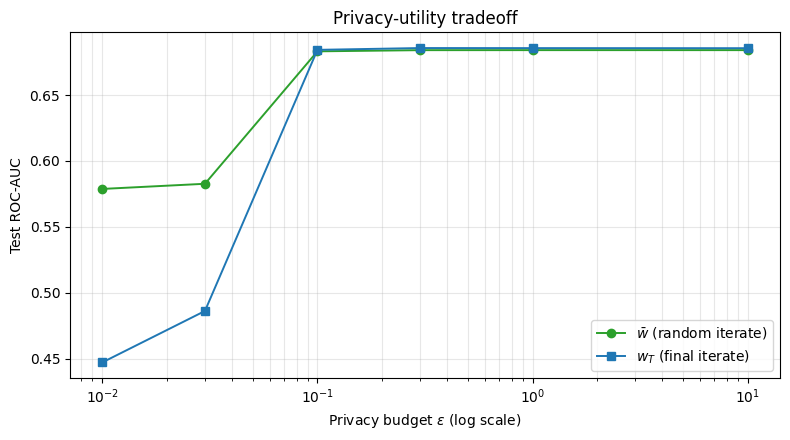

In [12]:
_ = viz.plot_epsilon_sweep(
    df['epsilon'].tolist(),
    df['auc_random'].tolist(),
    df['auc_final'].tolist(),
    FIGS_DIR / 'privacy_utility_tradeoff.png',
)